In [1]:
import sys
#change the next line to reflect where you have downloaded the source code
sys.path.insert(0, '../src')
import sbdynt as sbd

# *Example of some built-in scripts for plotting and reading simulation archive files*

We first have to have an example integration to work with. This is a chaotic TNO that is also resonant, which can be used to demonstrate basic and resonance-based plotting scripts

In [2]:
small_body = 'K00F53X'
data_directory = 'outputs-from-example-notebooks'
n_clones = 10
tmax = 5e6
tout = 1e3

In [3]:
iflag, epoch, sim = sbd.initialize_simulation(planets=['outer'], des=small_body, clones=n_clones)

if(iflag):
    #run the simulation, deleting any pre-existing archive file for this object
    rflag, sim = sbd.run_simulation(sim, des=small_body, datadir=data_directory, tmax=tmax, tout=tout,deletefile=True)


**Basic a-e-i time series plots**

All the plotting scripts can take pre-populated orbital element and time arrays, or they can read them from simulation archive files.

The first example here is an a-e-i plot using ``sbd.plot_aei``, where we will let the plotting script read the data from the default simulation archive file name generated from ``sbd.run_simulation`` above. If you used your own naming scheme, just pass that file name with the ``archivefile`` parameter.

This minimal call to ``sbd.plot_aei`` will return a flag and the matplotlib figure. The default is to plot all of the clones for the entire timespan in the simulation archivefile.

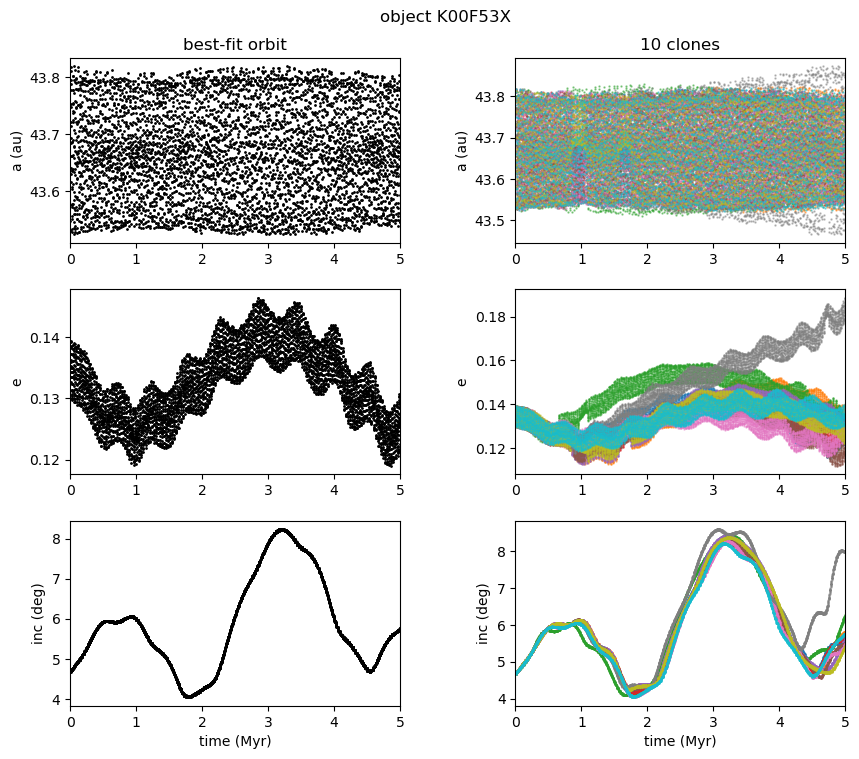

In [4]:
flag, aei_fig = sbd.plot_aei(des=small_body, datadir=data_directory)

If you want to plot just the best-fit orbit (or some number of clones that is smaller than all of them), use the **clones** parameter. 

You can also save a figure to a file in **datadir** using **figfile**. 

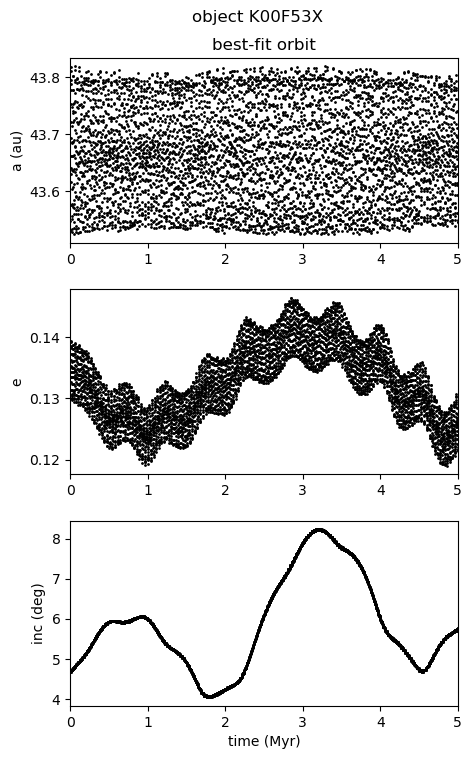

In [5]:
flag, aei_bf_fig = sbd.plot_aei(des=small_body, datadir=data_directory, clones=0, figfile='plot_aei-example.pdf')

**Example of reading the orbital elements from the simulation archive file and passing those to the plotting script**

If you want direct access to the orbital elements, you can read them using sbd.**read_sa_for_sbody**, and you can pass those orbital elements to the plotting script as an alternative to the script reading them from the archivefile


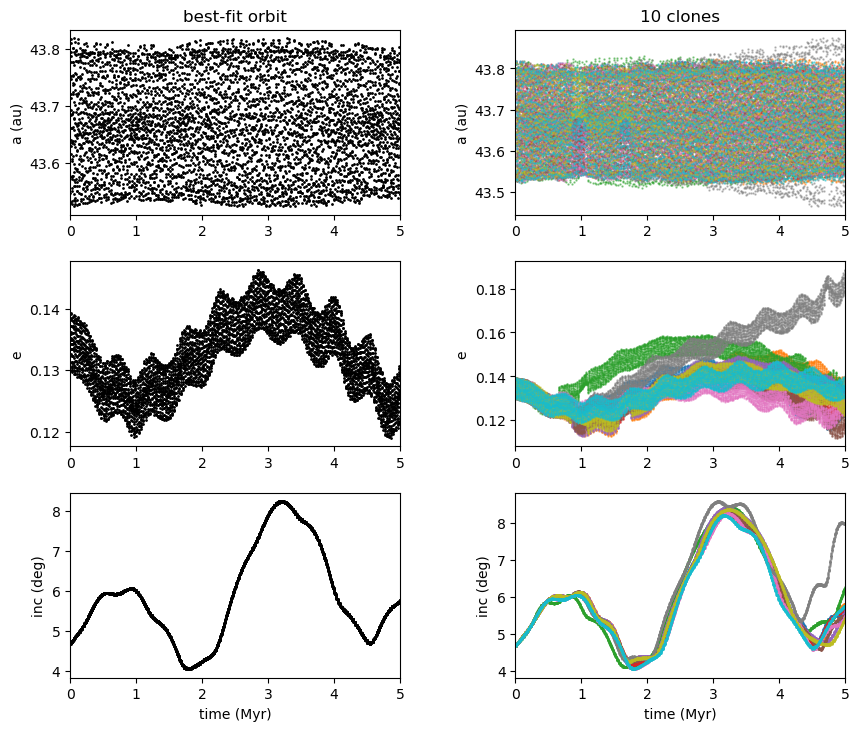

In [6]:
#reading all the clones (the best fit will be indexed 0, then clones)
flag, a, e, inc, node, aperi, ma, t  = sbd.read_sa_for_sbody(des=small_body, datadir = data_directory)
if(flag):
    flag, aei_fig = sbd.plot_aei(a=a, e=e, inc=inc,t=t)
    #note that if you want the object name in the plot title, pass des=small_body 

**Plots for resonant objects**

This object is in Neptune's 7:4 mean motion resonance, so we can generate a plot that also include the resonant angle using sbd.**plot_resonance**. 

If you want the plotting function to read from the archive file and calculate the resonant angle, you must specify the planet the resonance is with as well as (at a minimum) the integers **p** and **q** for the resonant angle 

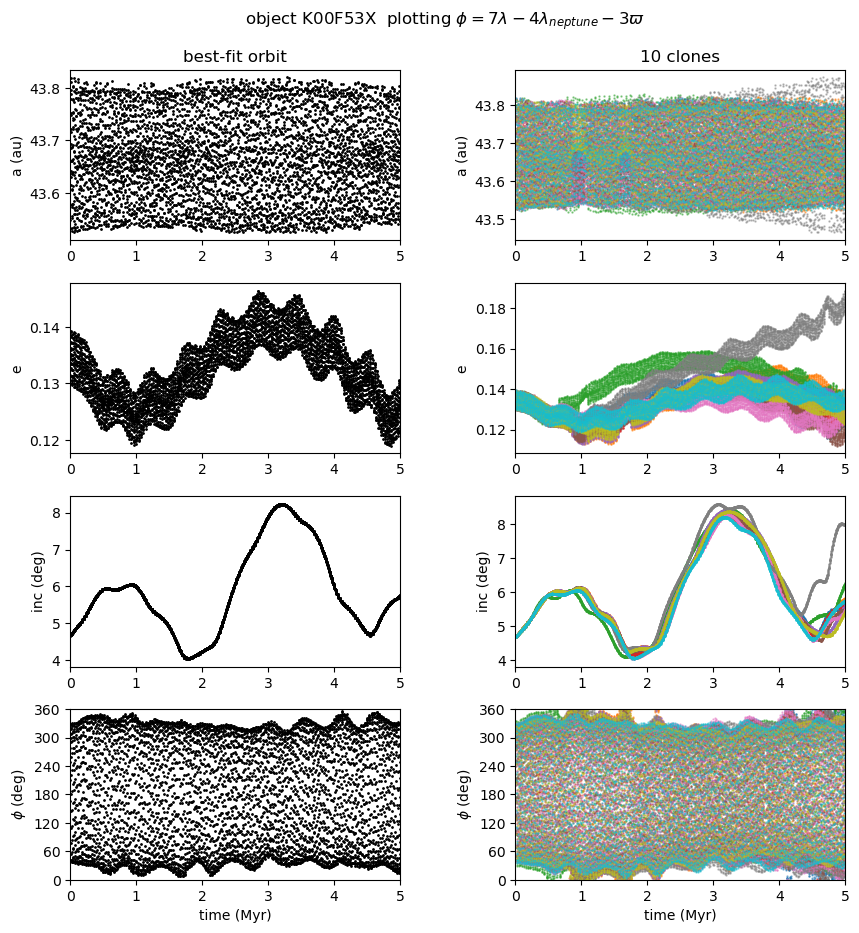

In [7]:
#default plotting function call
flag, res_fig = sbd.plot_resonance(des = small_body, planet='neptune',
                                   p=7,q=4,
                                   datadir = data_directory)

All the plotting calls also take **tmin** and **tmax** as inputs if you want to look at a smaller time range

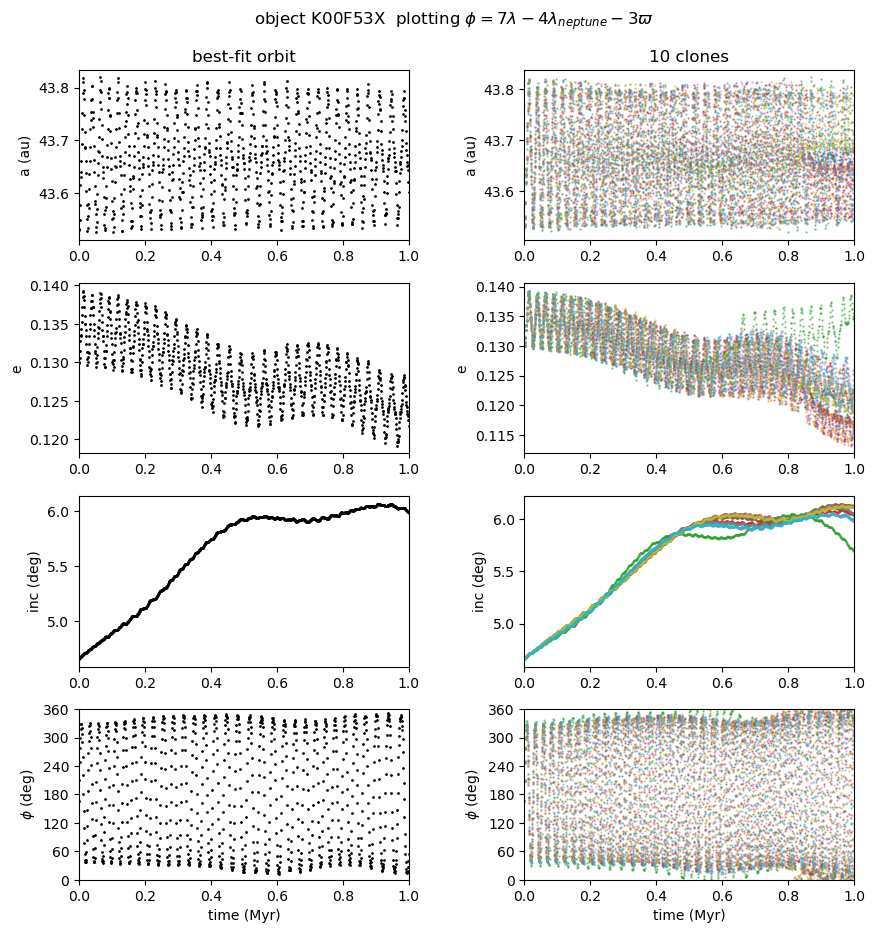

In [8]:
flag, res_fig2 = sbd.plot_resonance(des = small_body, planet='neptune',
                                    tmin=0.,tmax=1e6,
                                   p=7,q=4,
                                   datadir = data_directory)